In [2]:
import sys
sys.executable

'c:\\kalpesh\\1.ITvedant\\2.ML projects\\Silage_Sales_ML_Project\\venv\\Scripts\\python.exe'

In [3]:
import pandas as pd
from sqlalchemy import create_engine

In [4]:
username = "root"
password = "root"
host = "localhost"
port = "3306"
database = "Pancham_Silage_Factory_DB"

engine = create_engine(f"mysql+pymysql://{username}:{password}@{host}:{port}/{database}")

In [5]:
engine.connect()

In [6]:
version = sys.version
print(version)

3.10.11 (tags/v3.10.11:7d4cc5a, Apr  5 2023, 00:38:17) [MSC v.1929 64 bit (AMD64)]


# Smart Silage Pricing – Business EDA  
## Agricultural Supply Chain Analytics

## 1. Importing essential python libraries 

In [7]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns

import warnings
warnings.filterwarnings('ignore')

## 2. Dataset Loading

In [8]:
df = pd.read_sql("SELECT * FROM main_data", engine)
df.head()

,Transaction_ID,Date,Customer_Type,Crop_Type,Harvest_Season,Moisture_Content_Percent,DM_Content_Percent,Quantity_MT,Price_per_MT_INR,Total_Sales_INR,Logistics_Cost_INR,Profit_Margin_Percent,Payment_Mode,Credit_Period_Days,Bagging_Type
0,TXN2022-000077,2022-07-08,Co-operative,Maize,Kharif,69.1,30.9,9.37,6284.0,61682.71,2239.89,18.25,UPI,0,Bulk
1,TXN2022-000092,2022-09-28,Individual Farmer,Bajra,Kharif,67.4,32.6,8.23,7608.0,63157.02,3187.47,20.25,Credit,14,Bulk
2,TXN2022-000126,2022-12-06,Individual Farmer,Maize,Rabi,64.8,35.2,12.16,6885.0,91200.00,2247.52,10.59,Bank Transfer,0,Bags
3,TXN2022-000128,2022-12-06,Dairy Farm,Bajra,Rabi,59.1,40.9,3.43,6664.0,28088.27,3597.29,13.38,Credit,21,Bale-50kg
4,TXN2022-000133,2022-06-11,Individual Farmer,Jowar,Summer,68.4,31.6,5.69,8161.0,51966.77,2222.68,20.54,Bank Transfer,0,Bale-50kg


## 3. Data Cleaning & Preprocessing

In [9]:
df.info()
df.isnull().sum()
df.columns = df.columns.str.strip()
df.columns = df.columns.str.title()
df.fillna('0',inplace=True)
df.head()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 4759 entries, 0 to 4758
Data columns (total 15 columns):
 #   Column                    Non-Null Count  Dtype  
---  ------                    --------------  -----  
 0   Transaction_ID            4759 non-null   object 
 1   Date                      4759 non-null   object 
 2   Customer_Type             4759 non-null   object 
 3   Crop_Type                 4759 non-null   object 
 4   Harvest_Season            4759 non-null   object 
 5   Moisture_Content_Percent  4759 non-null   float64
 6   DM_Content_Percent        4759 non-null   float64
 7   Quantity_MT               4759 non-null   float64
 8   Price_per_MT_INR          4759 non-null   float64
 9   Total_Sales_INR           4759 non-null   float64
 10  Logistics_Cost_INR        4759 non-null   float64
 11  Profit_Margin_Percent     4759 non-null   float64
 12  Payment_Mode              4759 non-null   object 
 13  Credit_Period_Days        4759 non-null   int64  
 14  Bagging_

,Transaction_Id,Date,Customer_Type,Crop_Type,Harvest_Season,Moisture_Content_Percent,Dm_Content_Percent,Quantity_Mt,Price_Per_Mt_Inr,Total_Sales_Inr,Logistics_Cost_Inr,Profit_Margin_Percent,Payment_Mode,Credit_Period_Days,Bagging_Type
0,TXN2022-000077,2022-07-08,Co-operative,Maize,Kharif,69.1,30.9,9.37,6284.0,61682.71,2239.89,18.25,UPI,0,Bulk
1,TXN2022-000092,2022-09-28,Individual Farmer,Bajra,Kharif,67.4,32.6,8.23,7608.0,63157.02,3187.47,20.25,Credit,14,Bulk
2,TXN2022-000126,2022-12-06,Individual Farmer,Maize,Rabi,64.8,35.2,12.16,6885.0,91200.00,2247.52,10.59,Bank Transfer,0,Bags
3,TXN2022-000128,2022-12-06,Dairy Farm,Bajra,Rabi,59.1,40.9,3.43,6664.0,28088.27,3597.29,13.38,Credit,21,Bale-50kg
4,TXN2022-000133,2022-06-11,Individual Farmer,Jowar,Summer,68.4,31.6,5.69,8161.0,51966.77,2222.68,20.54,Bank Transfer,0,Bale-50kg


In [10]:
df['Date'] = pd.to_datetime(df['Date'], format='%d-%m-%Y')

In [11]:
df.columns

Index(['Transaction_Id', 'Date', 'Customer_Type', 'Crop_Type',
       'Harvest_Season', 'Moisture_Content_Percent', 'Dm_Content_Percent',
       'Quantity_Mt', 'Price_Per_Mt_Inr', 'Total_Sales_Inr',
       'Logistics_Cost_Inr', 'Profit_Margin_Percent', 'Payment_Mode',
       'Credit_Period_Days', 'Bagging_Type'],
      dtype='object')

In [12]:
df.head()

,Transaction_Id,Date,Customer_Type,Crop_Type,Harvest_Season,Moisture_Content_Percent,Dm_Content_Percent,Quantity_Mt,Price_Per_Mt_Inr,Total_Sales_Inr,Logistics_Cost_Inr,Profit_Margin_Percent,Payment_Mode,Credit_Period_Days,Bagging_Type
0,TXN2022-000077,2022-07-08,Co-operative,Maize,Kharif,69.1,30.9,9.37,6284.0,61682.71,2239.89,18.25,UPI,0,Bulk
1,TXN2022-000092,2022-09-28,Individual Farmer,Bajra,Kharif,67.4,32.6,8.23,7608.0,63157.02,3187.47,20.25,Credit,14,Bulk
2,TXN2022-000126,2022-12-06,Individual Farmer,Maize,Rabi,64.8,35.2,12.16,6885.0,91200.00,2247.52,10.59,Bank Transfer,0,Bags
3,TXN2022-000128,2022-12-06,Dairy Farm,Bajra,Rabi,59.1,40.9,3.43,6664.0,28088.27,3597.29,13.38,Credit,21,Bale-50kg
4,TXN2022-000133,2022-06-11,Individual Farmer,Jowar,Summer,68.4,31.6,5.69,8161.0,51966.77,2222.68,20.54,Bank Transfer,0,Bale-50kg


## 4.Feature Engineering`

In [13]:
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 4759 entries, 0 to 4758
Data columns (total 15 columns):
 #   Column                    Non-Null Count  Dtype         
---  ------                    --------------  -----         
 0   Transaction_Id            4759 non-null   object        
 1   Date                      4759 non-null   datetime64[ns]
 2   Customer_Type             4759 non-null   object        
 3   Crop_Type                 4759 non-null   object        
 4   Harvest_Season            4759 non-null   object        
 5   Moisture_Content_Percent  4759 non-null   float64       
 6   Dm_Content_Percent        4759 non-null   float64       
 7   Quantity_Mt               4759 non-null   float64       
 8   Price_Per_Mt_Inr          4759 non-null   float64       
 9   Total_Sales_Inr           4759 non-null   float64       
 10  Logistics_Cost_Inr        4759 non-null   float64       
 11  Profit_Margin_Percent     4759 non-null   float64       
 12  Payment_Mode        

In [14]:
def classify_quality(row):

    moisture = row["Moisture_Content_Percent"]

    # Ideal silage ranges
    if 62 <= moisture <= 68:
        return "High Quality Silage"

    else:
        return "Average Quality Silage"


df["Silage_Quality"] = df.apply(classify_quality, axis=1)



def quantity_discount(q):
    if q < 5:
        return 0.025
    elif q < 10:
        return 0.05
    elif q < 25:
        return 0.10
    else:
        return 0.15

df["Discount_rate"] = df["Quantity_Mt"].apply(quantity_discount).astype(float)




df.columns

Index(['Transaction_Id', 'Date', 'Customer_Type', 'Crop_Type',
       'Harvest_Season', 'Moisture_Content_Percent', 'Dm_Content_Percent',
       'Quantity_Mt', 'Price_Per_Mt_Inr', 'Total_Sales_Inr',
       'Logistics_Cost_Inr', 'Profit_Margin_Percent', 'Payment_Mode',
       'Credit_Period_Days', 'Bagging_Type', 'Silage_Quality',
       'Discount_rate'],
      dtype='object')

# EDA

In [15]:
# ===============================
# Global Chart Styling
# ===============================

sns.set_style("whitegrid")

plt.rcParams["figure.figsize"] = (12,5)
plt.rcParams["axes.titleweight"] = "bold"
plt.rcParams["axes.labelweight"] = "bold"

def style_chart(title, xlabel, ylabel):
    
    plt.title(title, fontsize=14, weight="bold")
    
    plt.xlabel(xlabel, fontsize=11, weight="bold")
    
    plt.ylabel(ylabel, fontsize=11, weight="bold")
    
    plt.xticks(fontsize=10, weight="bold")
    plt.yticks(fontsize=10, weight="bold")

def add_labels(ax, prefix="", suffix=""):
    
    for p in ax.patches:
        value = p.get_height()
        
        ax.annotate(
            f"{prefix}{value:,.0f}{suffix}",
            (p.get_x() + p.get_width()/2., value),
            ha="center",
            va="bottom",
            fontsize=11,
            fontweight="bold",
            xytext=(0,4),
            textcoords="offset points"
        )

### 1️⃣ Data Overview

In [16]:
# ===============================
# DATA OVERVIEW
# ===============================

print("Dataset Shape :", df.shape)

print("\nColumns :")
print(df.columns)

print("\nData Types :")
print(df.dtypes)

print("\nSample Data")
df.head()

Dataset Shape : (4759, 17)

Columns :
Index(['Transaction_Id', 'Date', 'Customer_Type', 'Crop_Type',
       'Harvest_Season', 'Moisture_Content_Percent', 'Dm_Content_Percent',
       'Quantity_Mt', 'Price_Per_Mt_Inr', 'Total_Sales_Inr',
       'Logistics_Cost_Inr', 'Profit_Margin_Percent', 'Payment_Mode',
       'Credit_Period_Days', 'Bagging_Type', 'Silage_Quality',
       'Discount_rate'],
      dtype='object')

Data Types :
Transaction_Id                      object
Date                        datetime64[ns]
Customer_Type                       object
Crop_Type                           object
Harvest_Season                      object
Moisture_Content_Percent           float64
Dm_Content_Percent                 float64
Quantity_Mt                        float64
Price_Per_Mt_Inr                   float64
Total_Sales_Inr                    float64
Logistics_Cost_Inr                 float64
Profit_Margin_Percent              float64
Payment_Mode                        object
Credit_Per

,Transaction_Id,Date,Customer_Type,Crop_Type,Harvest_Season,Moisture_Content_Percent,Dm_Content_Percent,Quantity_Mt,Price_Per_Mt_Inr,Total_Sales_Inr,Logistics_Cost_Inr,Profit_Margin_Percent,Payment_Mode,Credit_Period_Days,Bagging_Type,Silage_Quality,Discount_rate
0,TXN2022-000077,2022-07-08,Co-operative,Maize,Kharif,69.1,30.9,9.37,6284.0,61682.71,2239.89,18.25,UPI,0,Bulk,Average Quality Silage,0.050
1,TXN2022-000092,2022-09-28,Individual Farmer,Bajra,Kharif,67.4,32.6,8.23,7608.0,63157.02,3187.47,20.25,Credit,14,Bulk,High Quality Silage,0.050
2,TXN2022-000126,2022-12-06,Individual Farmer,Maize,Rabi,64.8,35.2,12.16,6885.0,91200.00,2247.52,10.59,Bank Transfer,0,Bags,High Quality Silage,0.100
3,TXN2022-000128,2022-12-06,Dairy Farm,Bajra,Rabi,59.1,40.9,3.43,6664.0,28088.27,3597.29,13.38,Credit,21,Bale-50kg,Average Quality Silage,0.025
4,TXN2022-000133,2022-06-11,Individual Farmer,Jowar,Summer,68.4,31.6,5.69,8161.0,51966.77,2222.68,20.54,Bank Transfer,0,Bale-50kg,Average Quality Silage,0.050


### 2️⃣ Missing Values Analysis

In [17]:
# ===============================
# MISSING VALUE ANALYSIS
# ===============================

missing = df.isnull().sum()

missing_df = pd.DataFrame({
    "Missing_Count": missing,
    "Missing_Percent": (missing/len(df))*100
}).sort_values("Missing_Count", ascending=False)

missing_df

,Missing_Count,Missing_Percent
Transaction_Id,0,0.0
Total_Sales_Inr,0,0.0
Silage_Quality,0,0.0
Bagging_Type,0,0.0
Credit_Period_Days,0,0.0
Payment_Mode,0,0.0
Profit_Margin_Percent,0,0.0
Logistics_Cost_Inr,0,0.0
Price_Per_Mt_Inr,0,0.0
Date,0,0.0


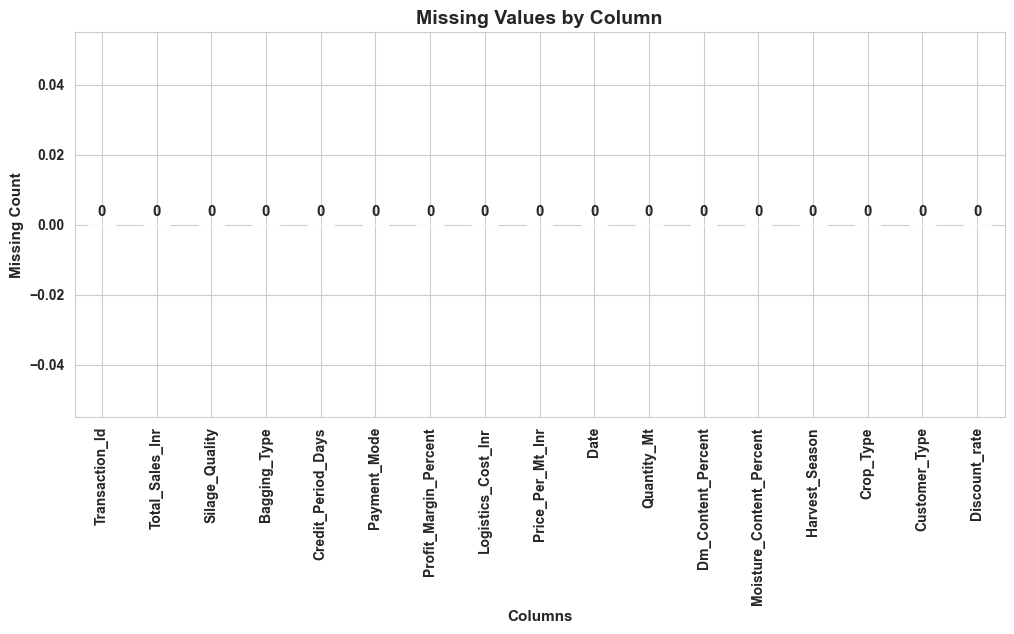

In [18]:
ax = missing_df["Missing_Count"].plot(kind="bar")

style_chart(
    "Missing Values by Column",
    "Columns",
    "Missing Count"
)

add_labels(ax)

plt.show()

### 3️⃣ Descriptive Statistics

In [19]:
# ===============================
# DESCRIPTIVE STATISTICS
# ===============================

df.describe().T

,count,mean,min,25%,50%,75%,max,std
Date,4759,2024-06-01 09:46:24.534566144,2022-01-26 00:00:00,2023-10-29 00:00:00,2024-07-26 00:00:00,2025-02-18 00:00:00,2025-08-14 00:00:00,NaN
Moisture_Content_Percent,4759.0,65.031141,58.0,63.1,65.0,67.5,72.0,3.143038
Dm_Content_Percent,4759.0,35.098592,28.0,32.7,35.1,37.4,42.0,3.26695
Quantity_Mt,4759.0,10.129586,1.4,6.38,8.98,12.67,30.0,5.111537
Price_Per_Mt_Inr,4759.0,7186.793024,5483.0,6693.5,7109.0,7624.0,9089.0,725.755046
Total_Sales_Inr,4759.0,70961.106411,9443.88,45662.87,63730.16,87178.035,241290.0,35064.804234
Logistics_Cost_Inr,4759.0,3192.26734,1339.63,2413.86,3138.87,3855.08,7186.3,975.3018
Profit_Margin_Percent,4759.0,14.522,6.0,12.47,14.54,16.65,25.0,3.09559
Credit_Period_Days,4759.0,3.91742,0.0,0.0,0.0,0.0,45.0,9.413982
Discount_rate,4759.0,0.068591,0.025,0.05,0.05,0.1,0.15,0.029811


In [20]:
numeric_cols = df.select_dtypes(include=["float64","int64"]).columns

stats = pd.DataFrame({
    "Mean": df[numeric_cols].mean(),
    "Median": df[numeric_cols].median(),
    "Std": df[numeric_cols].std(),
    "Min": df[numeric_cols].min(),
    "Max": df[numeric_cols].max()
})

stats

,Mean,Median,Std,Min,Max
Moisture_Content_Percent,65.031141,65.00,3.143038,58.000,72.00
Dm_Content_Percent,35.098592,35.10,3.266950,28.000,42.00
Quantity_Mt,10.129586,8.98,5.111537,1.400,30.00
Price_Per_Mt_Inr,7186.793024,7109.00,725.755046,5483.000,9089.00
Total_Sales_Inr,70961.106411,63730.16,35064.804234,9443.880,241290.00
Logistics_Cost_Inr,3192.267340,3138.87,975.301800,1339.630,7186.30
Profit_Margin_Percent,14.522000,14.54,3.095590,6.000,25.00
Credit_Period_Days,3.917420,0.00,9.413982,0.000,45.00
Discount_rate,0.068591,0.05,0.029811,0.025,0.15


### 4️⃣ Univariate Analysis (Distribution)

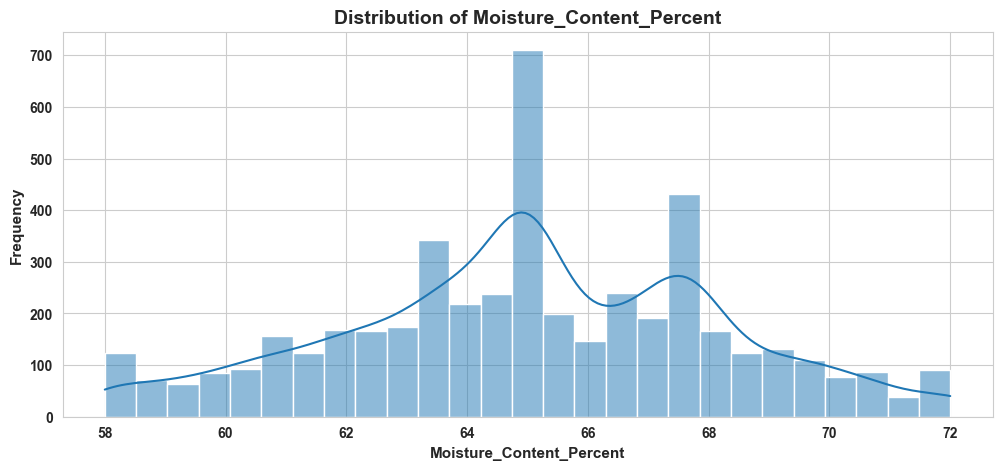

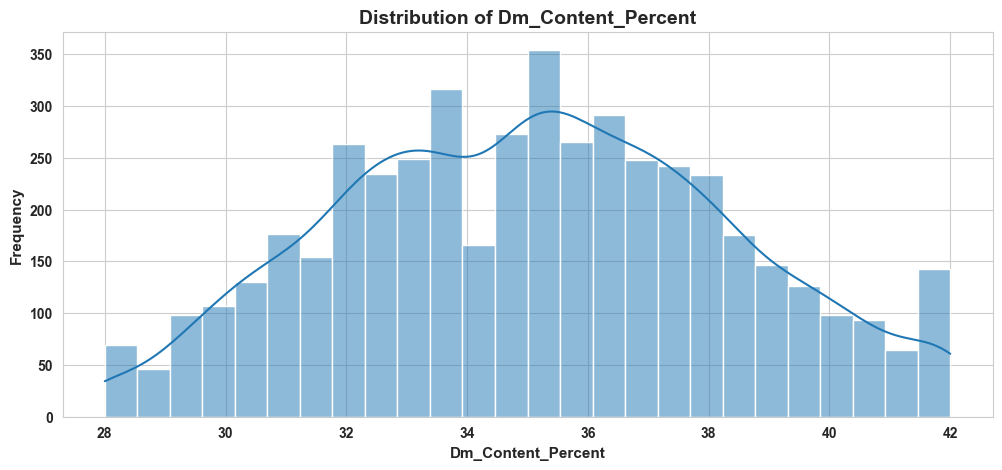

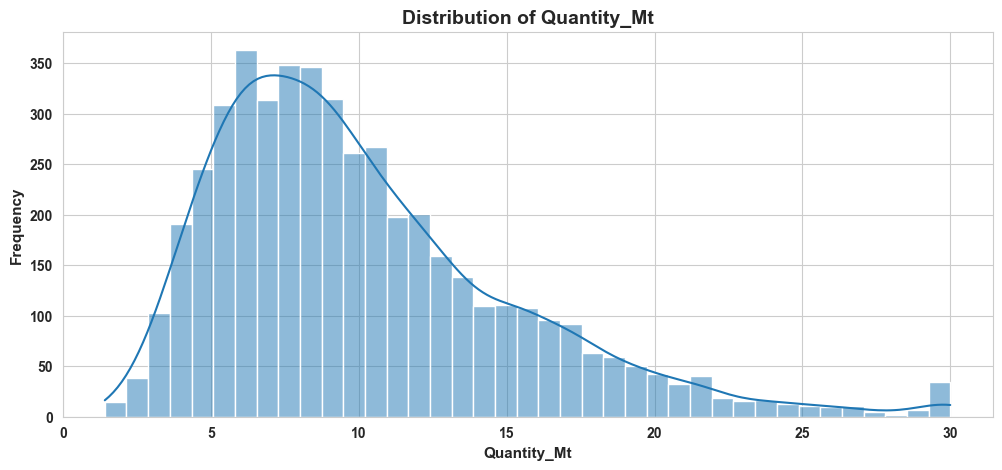

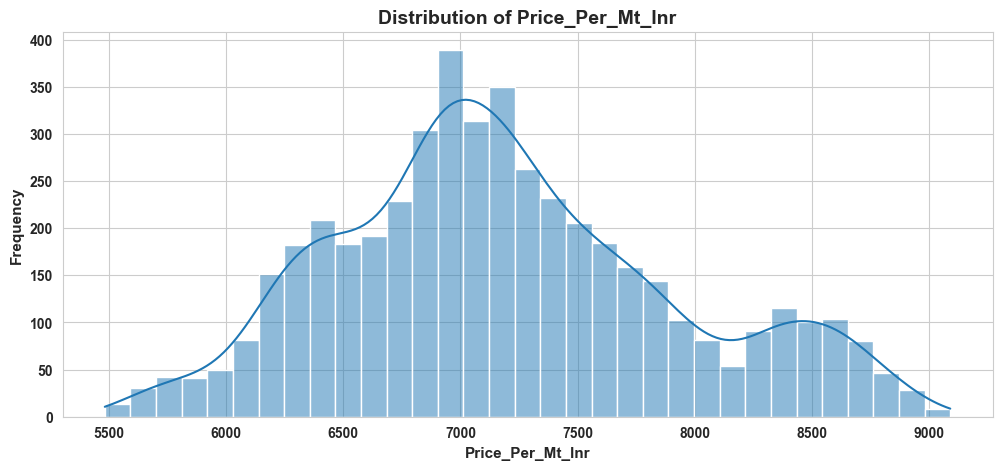

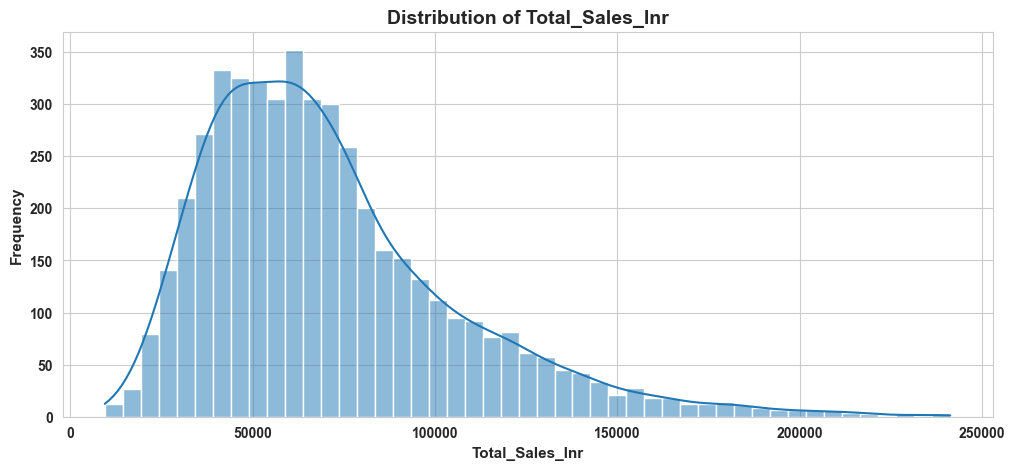

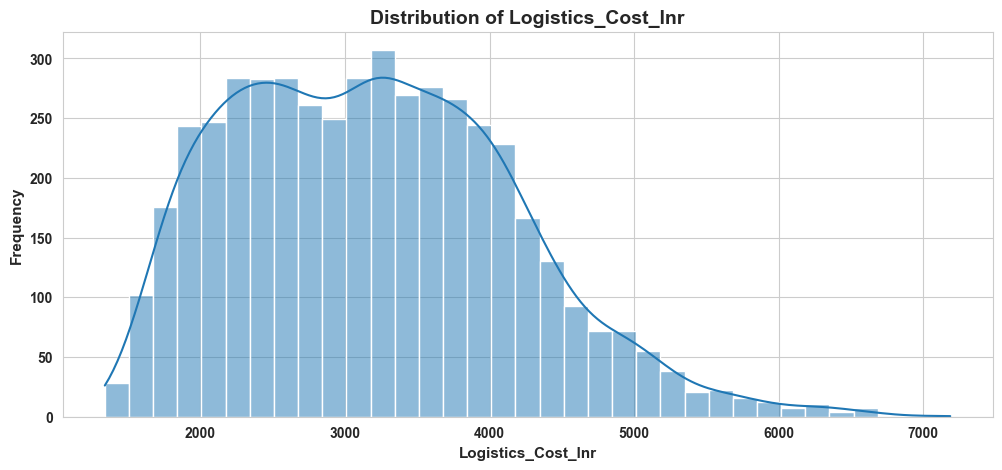

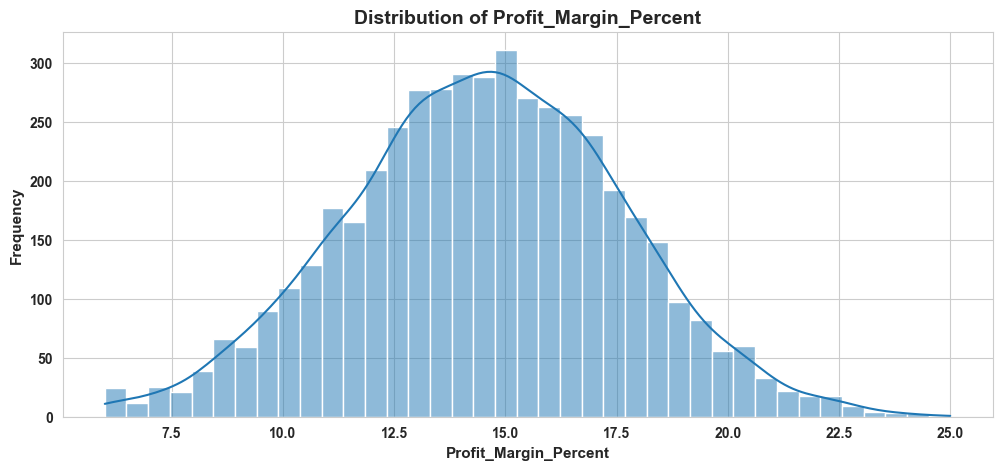

In [21]:
num_cols = [
    'Moisture_Content_Percent',
    'Dm_Content_Percent',
    'Quantity_Mt',
    'Price_Per_Mt_Inr',
    'Total_Sales_Inr',
    'Logistics_Cost_Inr',
    'Profit_Margin_Percent'
]

for col in num_cols:
    
    plt.figure()
    
    sns.histplot(df[col], kde=True)
    
    style_chart(
        f"Distribution of {col}",
        col,
        "Frequency"
    )
    
    plt.show()

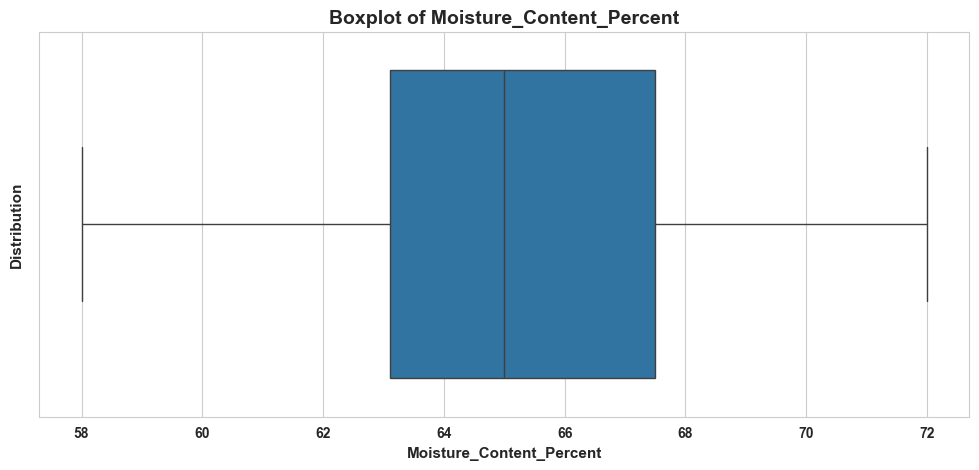

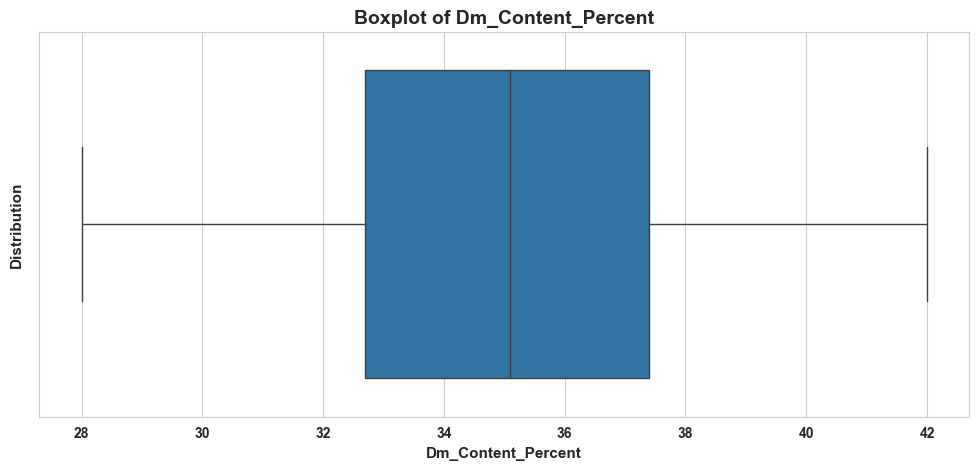

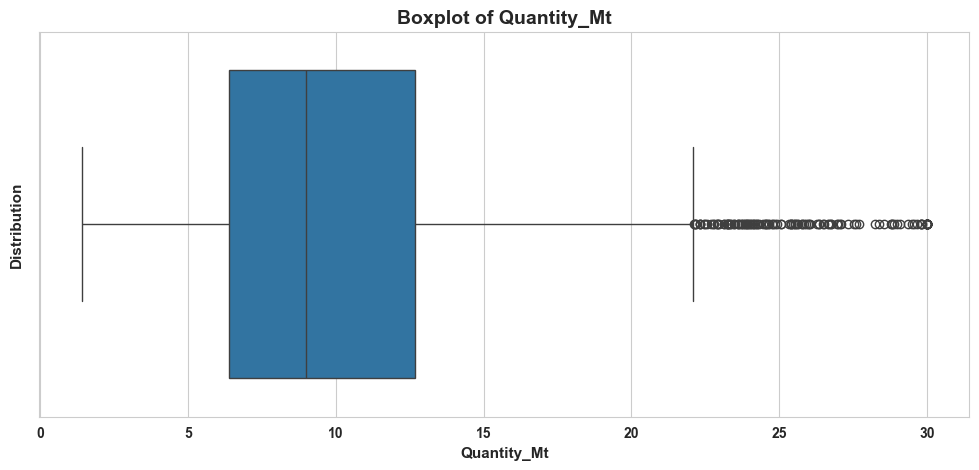

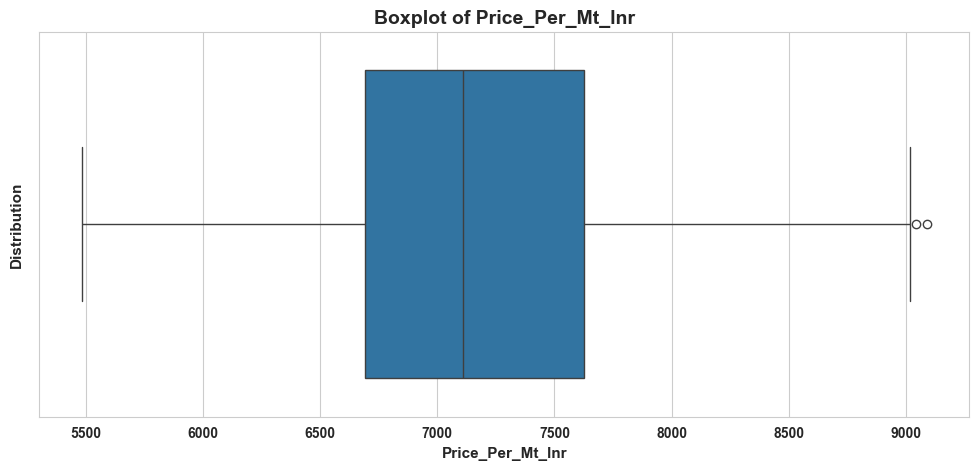

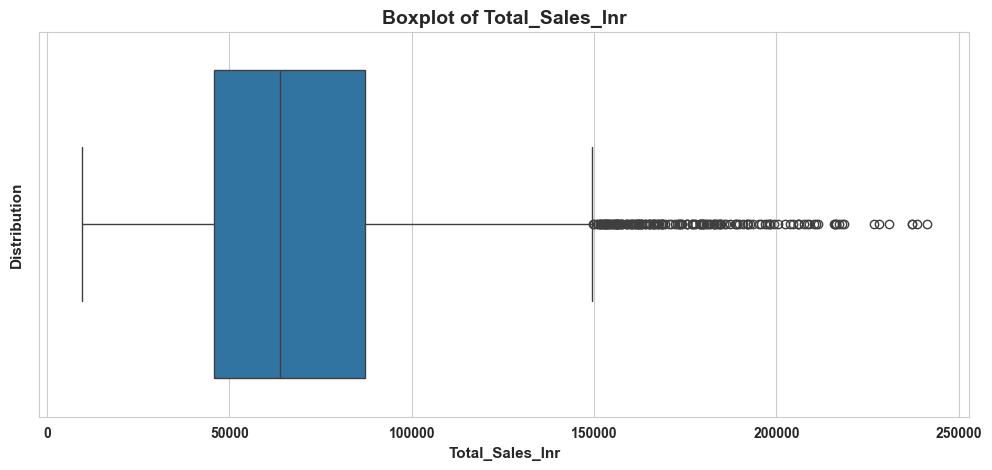

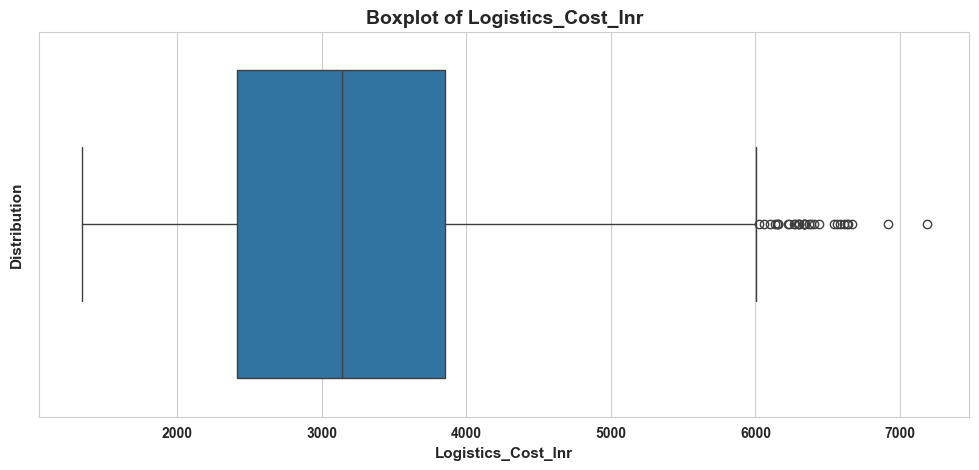

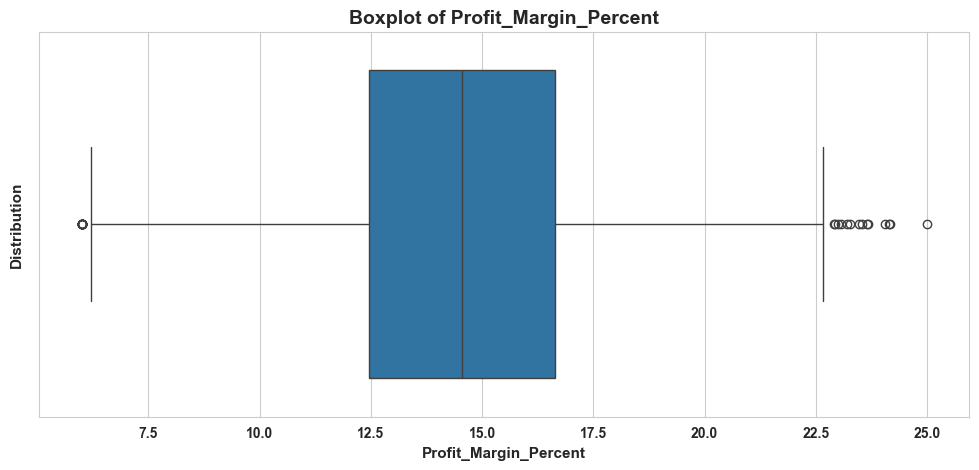

In [22]:
for col in num_cols:
    
    plt.figure()
    
    sns.boxplot(x=df[col])
    
    style_chart(
        f"Boxplot of {col}",
        col,
        "Distribution"
    )
    
    plt.show()

### 5️⃣ Bivariate Analysis

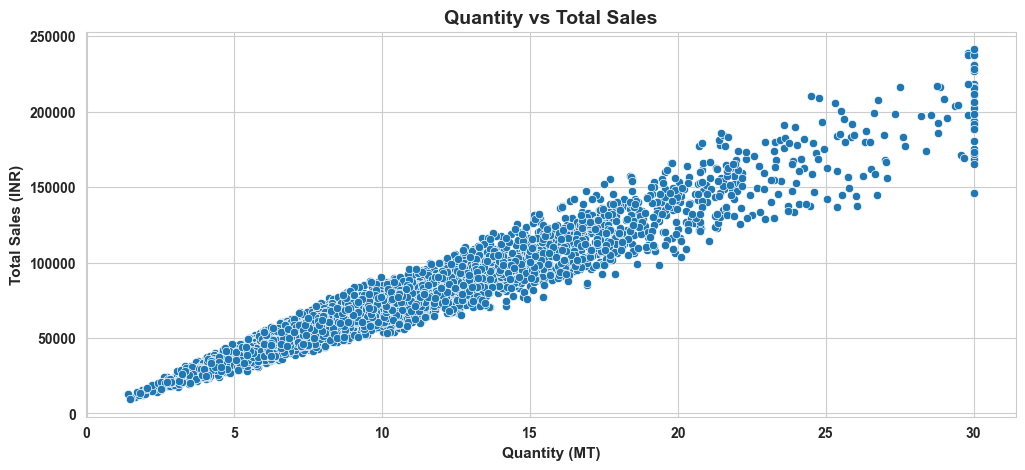

In [23]:
plt.figure()

sns.scatterplot(
    data=df,
    x="Quantity_Mt",
    y="Total_Sales_Inr"
)

style_chart(
    "Quantity vs Total Sales",
    "Quantity (MT)",
    "Total Sales (INR)"
)

plt.show()

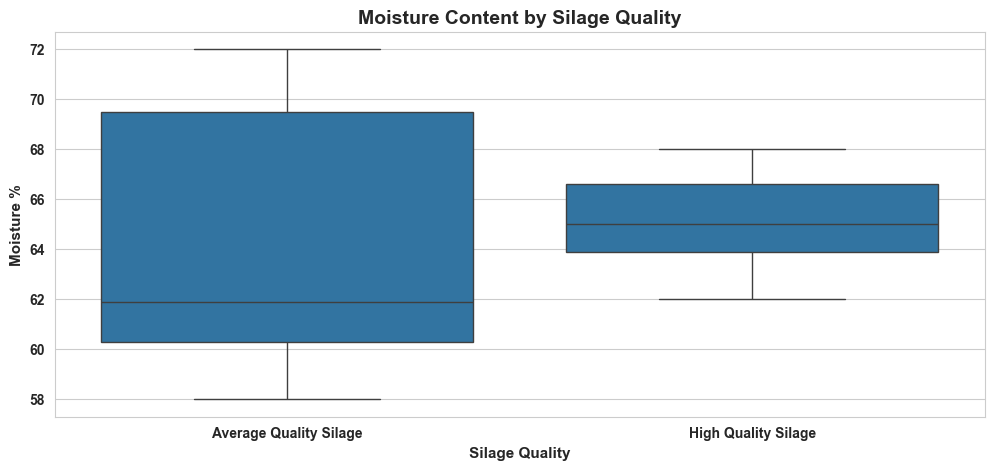

In [24]:
plt.figure()

sns.boxplot(
    data=df,
    x="Silage_Quality",
    y="Moisture_Content_Percent"
)

style_chart(
    "Moisture Content by Silage Quality",
    "Silage Quality",
    "Moisture %"
)

plt.show()

### 6️⃣ Correlation Analysis

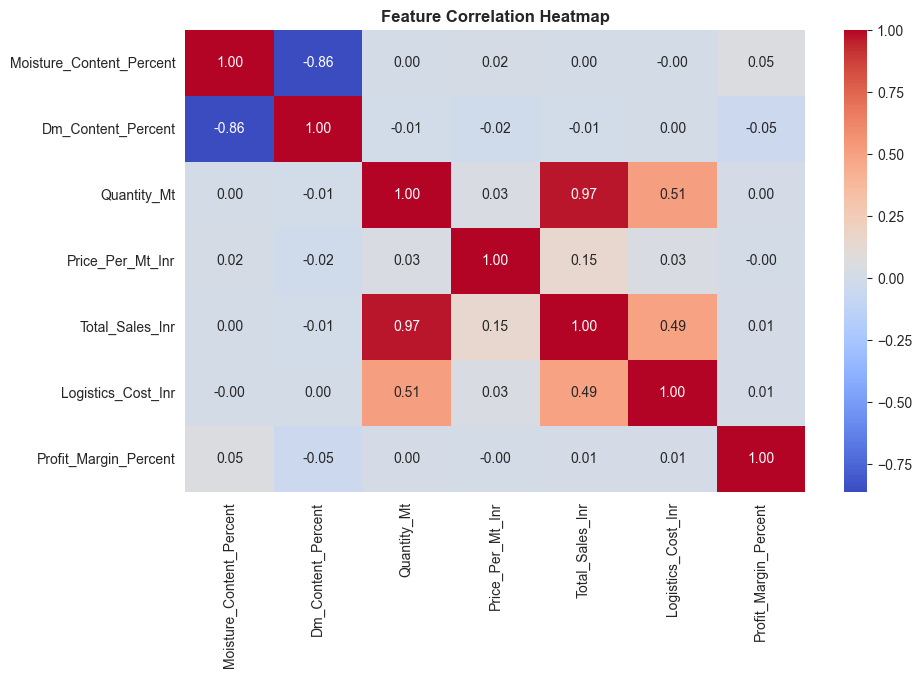

In [25]:
# ===============================
# CORRELATION MATRIX
# ===============================

corr = df[num_cols].corr()

plt.figure(figsize=(10,6))

sns.heatmap(
    corr,
    annot=True,
    cmap="coolwarm",
    fmt=".2f"
)

plt.title("Feature Correlation Heatmap", weight="bold")

plt.show()

### 7️⃣ Outlier Detection

In [26]:
# ===============================
# OUTLIER DETECTION
# ===============================

for col in num_cols:

    Q1 = df[col].quantile(0.25)
    
    Q3 = df[col].quantile(0.75)
    
    IQR = Q3 - Q1
    
    lower = Q1 - 1.5 * IQR
    
    upper = Q3 + 1.5 * IQR
    
    outliers = df[(df[col] < lower) | (df[col] > upper)]
    
    print(f"{col} Outliers :", len(outliers))

Moisture_Content_Percent Outliers : 0
Dm_Content_Percent Outliers : 0
Quantity_Mt Outliers : 136
Price_Per_Mt_Inr Outliers : 2
Total_Sales_Inr Outliers : 168
Logistics_Cost_Inr Outliers : 31
Profit_Margin_Percent Outliers : 34


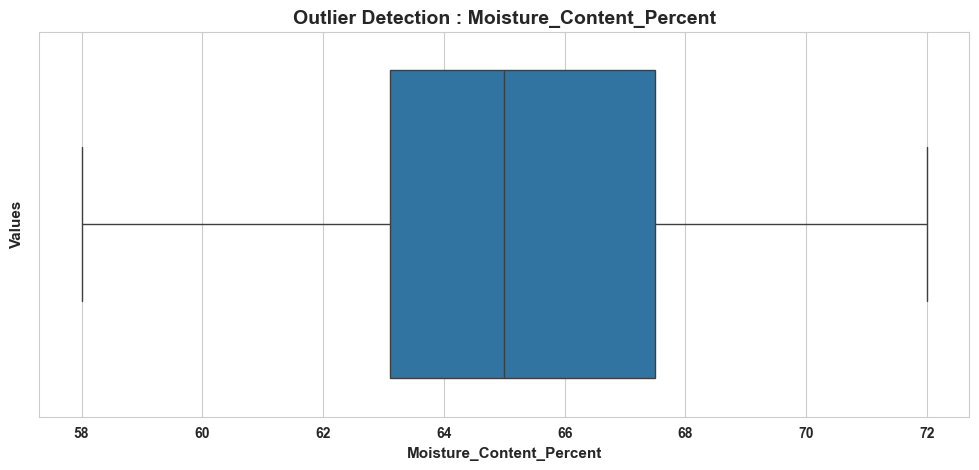

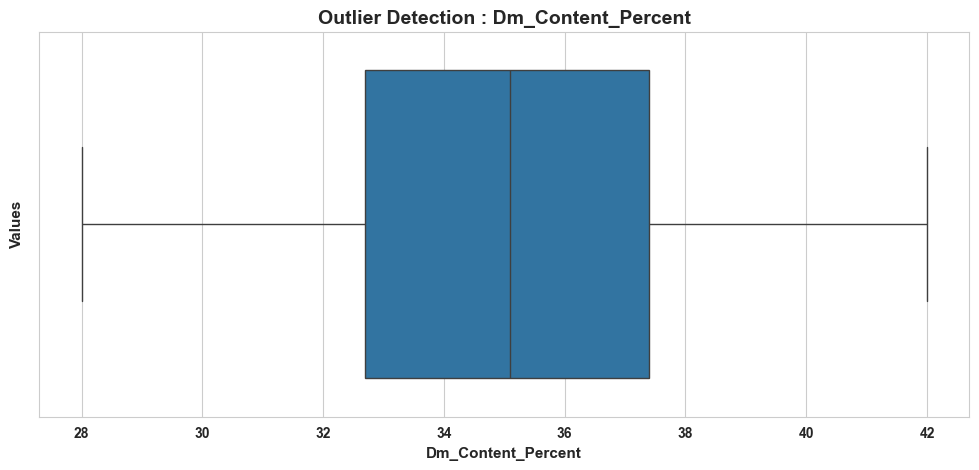

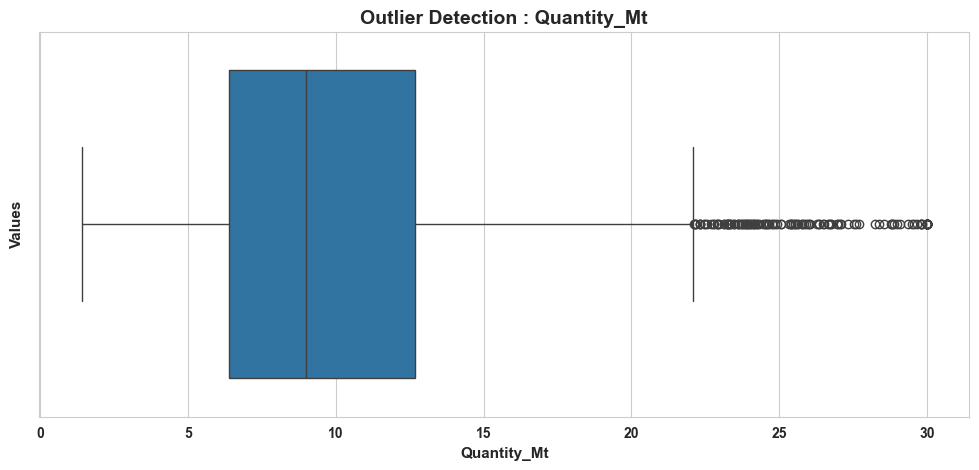

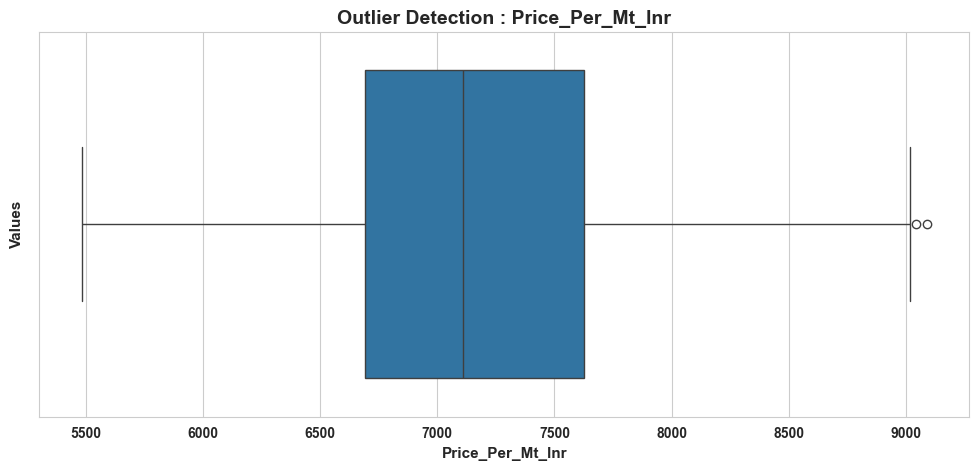

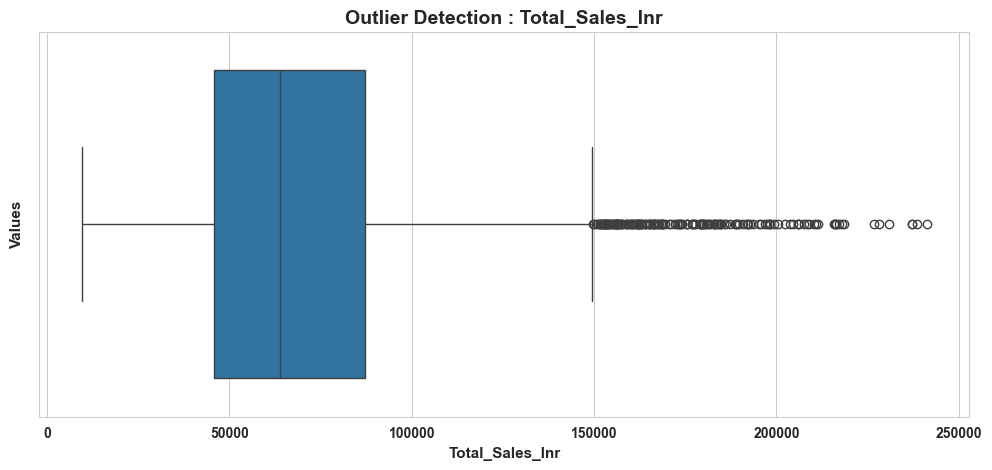

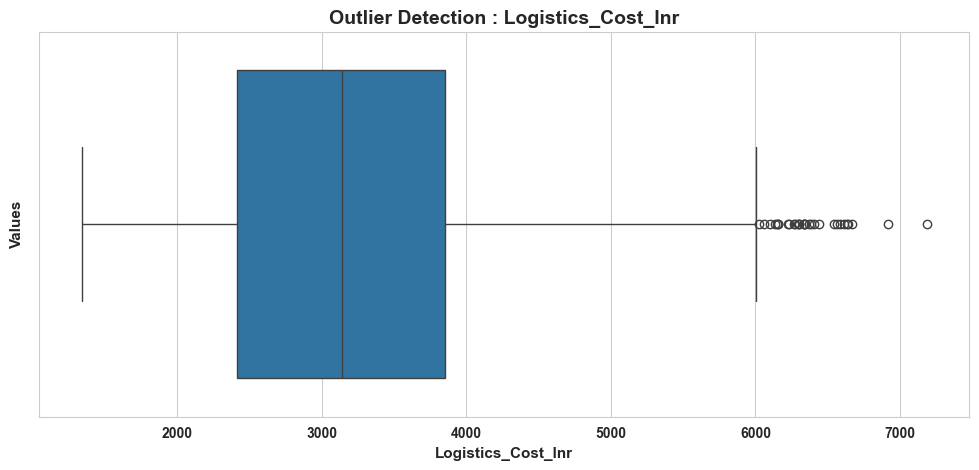

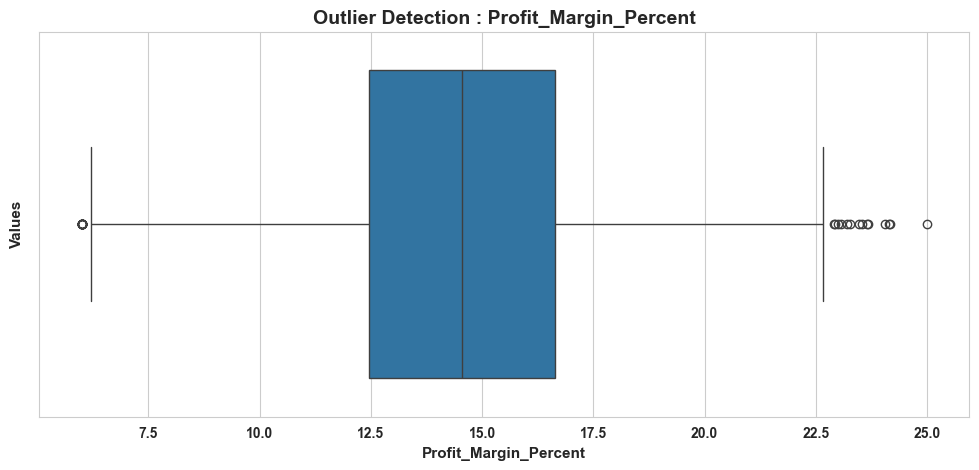

In [27]:
for col in num_cols:
    
    plt.figure()
    
    sns.boxplot(x=df[col])
    
    style_chart(
        f"Outlier Detection : {col}",
        col,
        "Values"
    )
    
    plt.show()

### 8️⃣ Feature Distribution (Skewness)

In [28]:
skewness = df[num_cols].skew()

skew_df = pd.DataFrame({
    "Feature": skewness.index,
    "Skewness": skewness.values
})

skew_df

,Feature,Skewness
0,Moisture_Content_Percent,-0.092591
1,Dm_Content_Percent,0.053433
2,Quantity_Mt,1.195245
3,Price_Per_Mt_Inr,0.358338
4,Total_Sales_Inr,1.261796
5,Logistics_Cost_Inr,0.495551
6,Profit_Margin_Percent,-0.029026


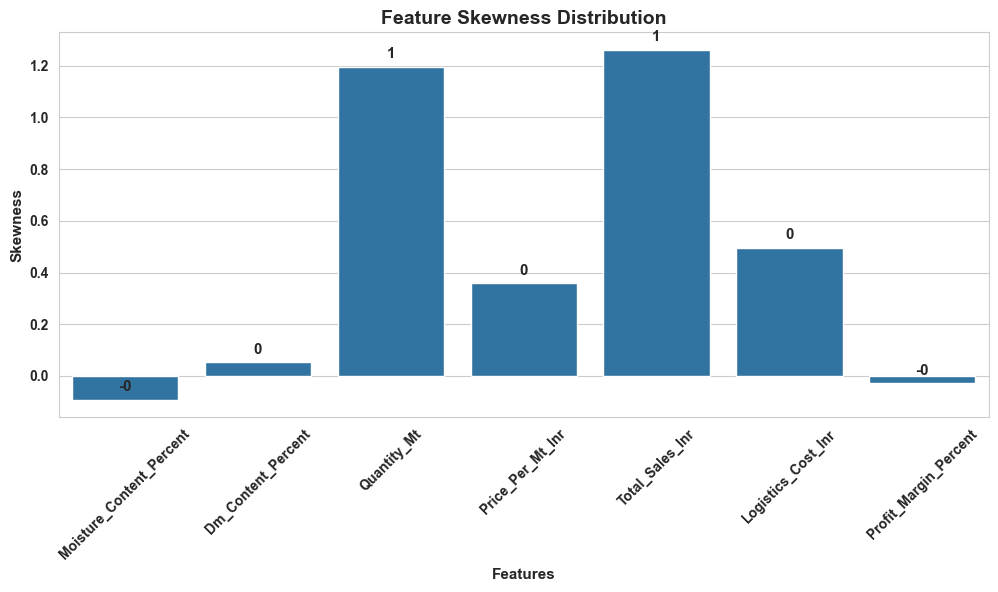

In [29]:
ax = sns.barplot(
    data=skew_df,
    x="Feature",
    y="Skewness"
)

style_chart(
    "Feature Skewness Distribution",
    "Features",
    "Skewness"
)

plt.xticks(rotation=45)

add_labels(ax)

plt.show()

### 9️⃣ Category Analysis

Sales by Crop Type

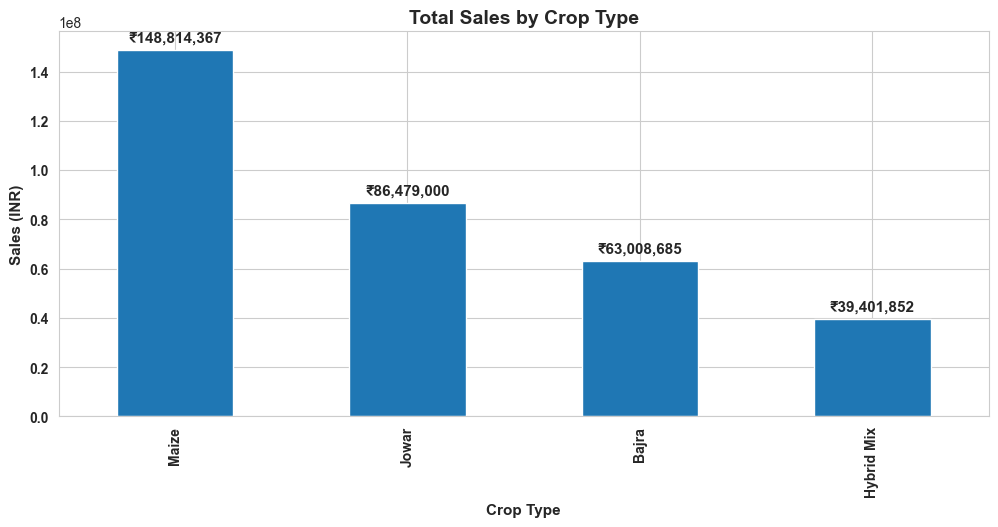

In [30]:
sales_crop = df.groupby("Crop_Type")["Total_Sales_Inr"].sum().sort_values(ascending=False)

ax = sales_crop.plot(kind="bar")

style_chart(
    "Total Sales by Crop Type",
    "Crop Type",
    "Sales (INR)"
)

add_labels(ax, prefix="₹")

plt.show()

Sales by Customer Type

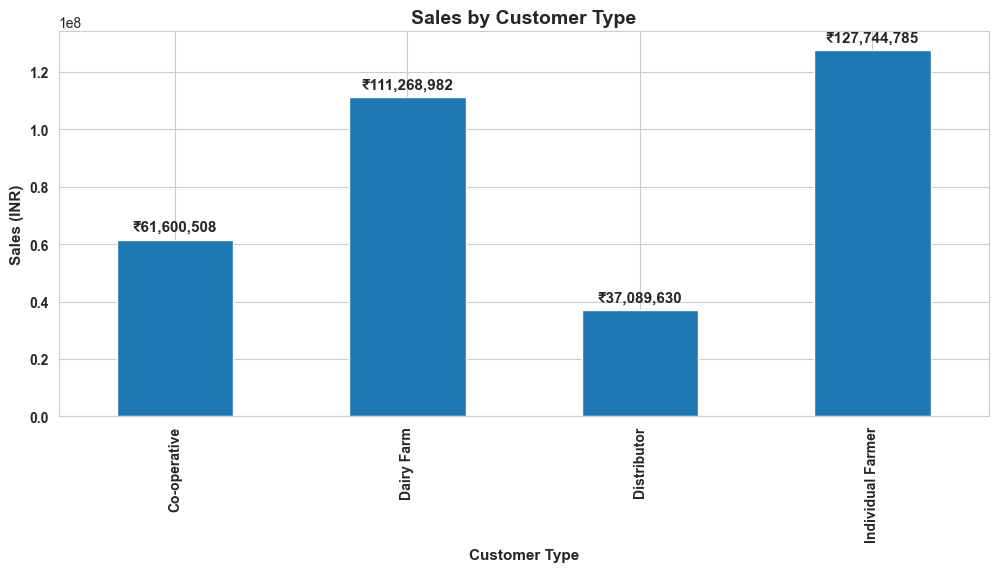

In [31]:
sales_customer = df.groupby("Customer_Type")["Total_Sales_Inr"].sum()

ax = sales_customer.plot(kind="bar")

style_chart(
    "Sales by Customer Type",
    "Customer Type",
    "Sales (INR)"
)

add_labels(ax, prefix="₹")

plt.show()

### 🔟 Payment Mode Analysis

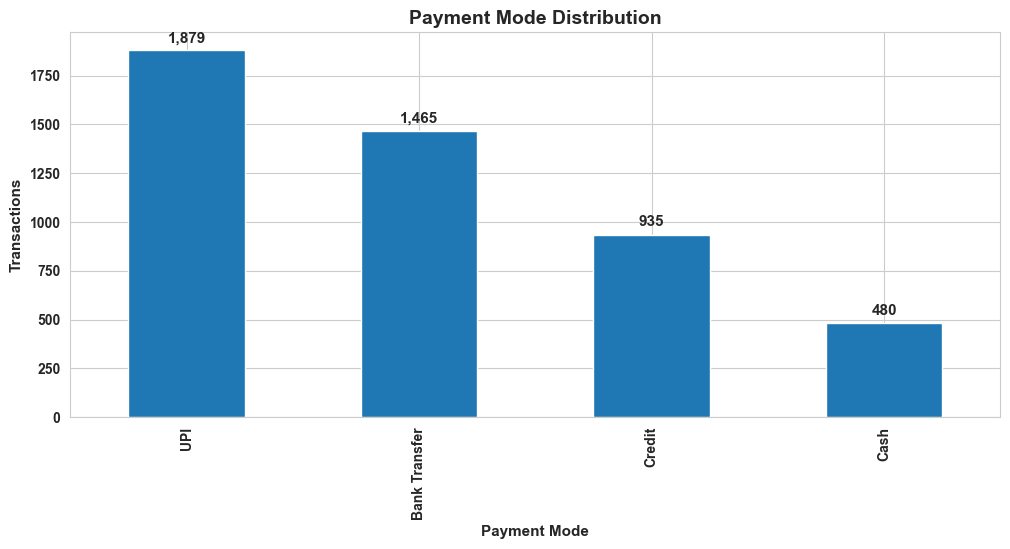

In [32]:
payment = df["Payment_Mode"].value_counts()

ax = payment.plot(kind="bar")

style_chart(
    "Payment Mode Distribution",
    "Payment Mode",
    "Transactions"
)

add_labels(ax)

plt.show()